<a href="https://colab.research.google.com/github/Ashima010302/PCS221/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

roll_number =25
np.random.seed(roll_number)

In [36]:
sales_data = np.random.randint(1000, 5000, size=(12,4))

sales_data

array([[2156, 1318, 3522, 3191],
       [4389, 3934, 1255, 2175],
       [3988, 2970, 1765, 2160],
       [4228, 2924, 2881, 4325],
       [3975, 1500, 3501, 3689],
       [1167, 4843, 4160, 3999],
       [4331, 1852, 3861, 3179],
       [3817, 3454, 1927, 1304],
       [2583, 4273, 4728, 2516],
       [3157, 1562, 1981, 1548],
       [3697, 4232, 4722, 3876],
       [1303, 4178, 2793, 3006]])

In [37]:
columns = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']
months = pd.date_range(start='2023-01-01', periods=12, freq='MS').strftime('%b')

sales_df = pd.DataFrame(sales_data, columns=columns, index=months)
display(sales_df)

,Electronics,Clothing,Home & Kitchen,Sports
Jan,2156,1318,3522,3191
Feb,4389,3934,1255,2175
Mar,3988,2970,1765,2160
Apr,4228,2924,2881,4325
May,3975,1500,3501,3689
Jun,1167,4843,4160,3999
Jul,4331,1852,3861,3179
Aug,3817,3454,1927,1304
Sep,2583,4273,4728,2516
Oct,3157,1562,1981,1548


In [38]:
sales_data = np.random.randint(1000, 5000, size=(12,4))

sales_data


array([[2755, 2457, 4474, 1604],
       [1804, 4426, 2438, 4045],
       [1872, 1235, 3800, 3726],
       [3676, 4202, 1261, 2081],
       [2481, 1022, 4056, 2291],
       [4586, 1171, 1602, 4901],
       [4284, 3771, 4018, 2681],
       [1014, 2491, 1933, 4690],
       [3007, 1306, 4635, 1782],
       [1327, 2726, 4546, 1783],
       [3574, 2100, 2319, 3648],
       [4246, 1883, 1693, 2253]])

In [39]:
# 1. Display the first 5 rows and summary statistics of the DataFrame
print("First 5 rows of the DataFrame:")
display(sales_df.head())

print("\nSummary statistics of the DataFrame:")
display(sales_df.describe())

First 5 rows of the DataFrame:


,Electronics,Clothing,Home & Kitchen,Sports
Jan,2156,1318,3522,3191
Feb,4389,3934,1255,2175
Mar,3988,2970,1765,2160
Apr,4228,2924,2881,4325
May,3975,1500,3501,3689



Summary statistics of the DataFrame:


,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,3232.583333,3086.666667,3091.333333,2914.000000
std,1159.559670,1257.073538,1178.540032,980.757129
min,1167.000000,1318.000000,1255.000000,1304.000000
25%,2476.250000,1779.500000,1967.500000,2171.250000
50%,3757.000000,3212.000000,3191.000000,3092.500000
75%,4048.000000,4191.500000,3935.750000,3735.750000
max,4389.000000,4843.000000,4728.000000,4325.000000


In [40]:
# 2. Calculate the total sales per category and total sales per month
total_sales_per_category = sales_df.sum()
print("\nTotal Sales Per Category:")
display(total_sales_per_category)

total_sales_per_month = sales_df.sum(axis=1)
print("\nTotal Sales Per Month:")
display(total_sales_per_month)


Total Sales Per Category:


,0
Electronics,38791
Clothing,37040
Home & Kitchen,37096
Sports,34968



Total Sales Per Month:


,0
Jan,10187
Feb,11753
Mar,10883
Apr,14358
May,12665
Jun,14169
Jul,13223
Aug,10502
Sep,14100
Oct,8248


In [41]:
# 3. Calculate the average sales growth between consecutive months for each category
sales_growth_per_category = sales_df.pct_change()
average_sales_growth_per_category = sales_growth_per_category.mean()
print("\nAverage Sales Growth Between Consecutive Months Per Category:")
display(average_sales_growth_per_category)


Average Sales Growth Between Consecutive Months Per Category:


,0
Electronics,0.204841
Clothing,0.455694
Home & Kitchen,0.188485
Sports,0.149388


In [42]:
# 4. Add the following columns to the DataFrame:

sales_df_modified = sales_df.copy()
sales_df_modified['Total Sales'] = sales_df_modified[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']].sum(axis=1)
sales_df_modified['Growth Rate'] = sales_df_modified['Total Sales'].pct_change() * 100

print("\nDataFrame with 'Total Sales' and 'Growth Rate' columns added:")
display(sales_df_modified)


DataFrame with 'Total Sales' and 'Growth Rate' columns added:


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2156,1318,3522,3191,10187,NaN
Feb,4389,3934,1255,2175,11753,15.372534
Mar,3988,2970,1765,2160,10883,-7.402365
Apr,4228,2924,2881,4325,14358,31.930534
May,3975,1500,3501,3689,12665,-11.791336
Jun,1167,4843,4160,3999,14169,11.875247
Jul,4331,1852,3861,3179,13223,-6.676547
Aug,3817,3454,1927,1304,10502,-20.577781
Sep,2583,4273,4728,2516,14100,34.260141
Oct,3157,1562,1981,1548,8248,-41.503546


In [43]:
# 5. Apply a randomized discount based on roll_number

sales_df_final = sales_df_modified.copy()

print(f"Original sales data for 'Clothing' (first 5 rows before discount):\n{sales_df_final['Clothing'].head().to_string()}")

# The roll_number is 25, which is odd.
if roll_number % 2 == 0:
    sales_df_final['Electronics'] *= 0.90 # 10% discount
    print(f"\nApplying 10% discount to 'Electronics' as roll number ({roll_number}) is even.")
else:
    sales_df_final['Clothing'] *= 0.85 # 15% discount
    print(f"\nApplying 15% discount to 'Clothing' as roll number ({roll_number}) is odd.")

print("\nDataFrame after applying discount:")
display(sales_df_final)
print(f"New sales data for 'Clothing' (first 5 rows after discount):\n{sales_df_final['Clothing'].head().to_string()}")

Original sales data for 'Clothing' (first 5 rows before discount):
Jan    1318
Feb    3934
Mar    2970
Apr    2924
May    1500

Applying 15% discount to 'Clothing' as roll number (25) is odd.

DataFrame after applying discount:


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2156,1120.30,3522,3191,10187,NaN
Feb,4389,3343.90,1255,2175,11753,15.372534
Mar,3988,2524.50,1765,2160,10883,-7.402365
Apr,4228,2485.40,2881,4325,14358,31.930534
May,3975,1275.00,3501,3689,12665,-11.791336
Jun,1167,4116.55,4160,3999,14169,11.875247
Jul,4331,1574.20,3861,3179,13223,-6.676547
Aug,3817,2935.90,1927,1304,10502,-20.577781
Sep,2583,3632.05,4728,2516,14100,34.260141
Oct,3157,1327.70,1981,1548,8248,-41.503546


New sales data for 'Clothing' (first 5 rows after discount):
Jan    1120.3
Feb    3343.9
Mar    2524.5
Apr    2485.4
May    1275.0


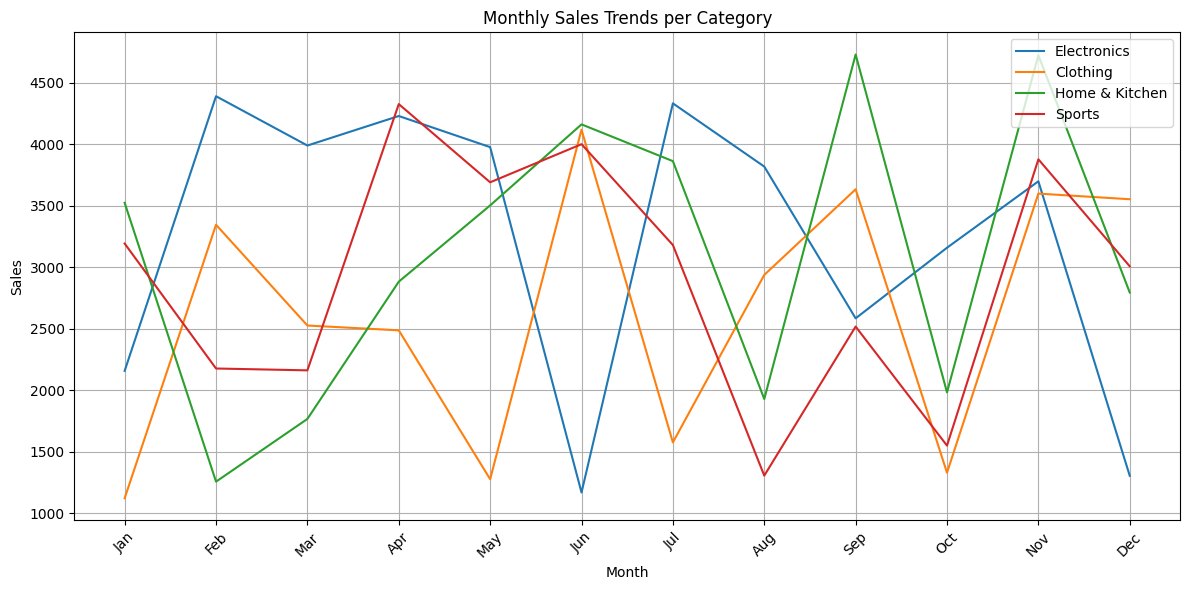

In [44]:
# 1. Plot monthly sales trends for each category using line plots.

plt.figure(figsize=(12, 6))
for column in ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']:
    sns.lineplot(x=sales_df_final.index, y=sales_df_final[column], label=column)

plt.title('Monthly Sales Trends per Category')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

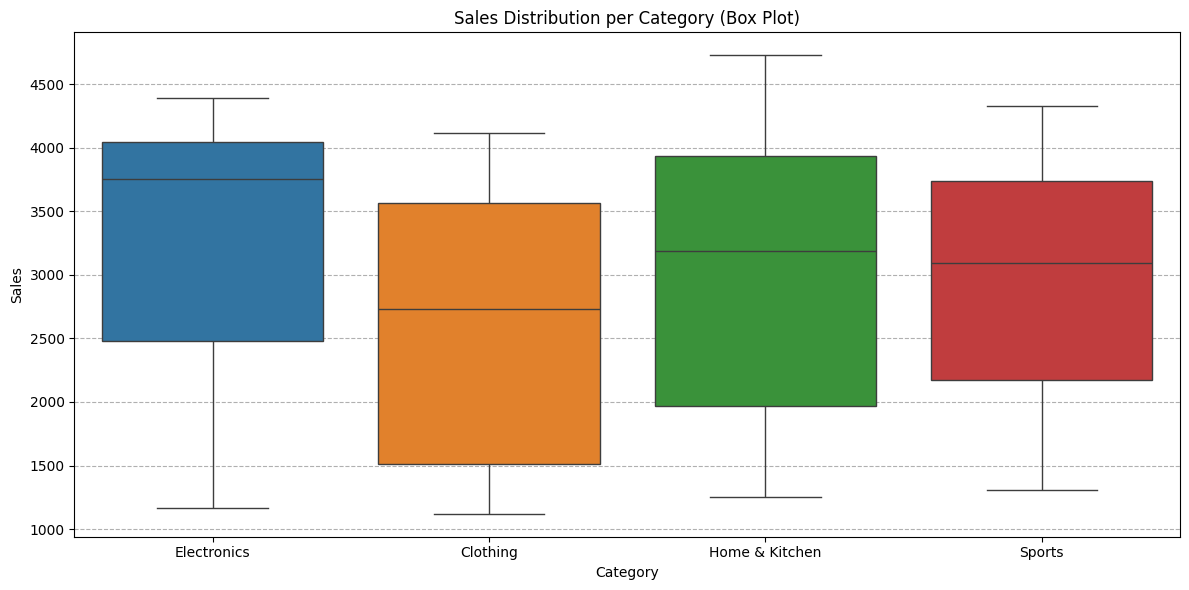

In [45]:
# 2. Create box plots to show the sales distribution for each category.

plt.figure(figsize=(12, 6))
sns.boxplot(data=sales_df_final[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']])

plt.title('Sales Distribution per Category (Box Plot)')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

Ques 2

In [46]:
import numpy as np

array = np.array([[1, -2, 3],[-4, 5, -6]])
print("Original Array:")
display(array)

Original Array:


array([[ 1, -2,  3],
       [-4,  5, -6]])

In [47]:
# i. Find element-wise absolute value
print("Element-wise Absolute Value:")
display(np.abs(array))

Element-wise Absolute Value:


array([[1, 2, 3],
       [4, 5, 6]])

In [48]:
# ii. Find the 25th, 50th, and 75th percentile

# Flattened array
print("Percentiles (25th, 50th, 75th) of Flattened Array:")
percentiles_flattened = np.percentile(array.flatten(), [25, 50, 75])
display(percentiles_flattened)

# For each column (axis=0)
print("\nPercentiles (25th, 50th, 75th) for Each Column:")
percentiles_columns = np.percentile(array, [25, 50, 75], axis=0)
display(percentiles_columns)

# For each row (axis=1)
print("\nPercentiles (25th, 50th, 75th) for Each Row:")
percentiles_rows = np.percentile(array, [25, 50, 75], axis=1)
display(percentiles_rows)

Percentiles (25th, 50th, 75th) of Flattened Array:


array([-3.5, -0.5,  2.5])


Percentiles (25th, 50th, 75th) for Each Column:


array([[-2.75, -0.25, -3.75],
       [-1.5 ,  1.5 , -1.5 ],
       [-0.25,  3.25,  0.75]])


Percentiles (25th, 50th, 75th) for Each Row:


array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

In [49]:
# iii. Mean, Median and Standard Deviation

# Flattened array
print("Mean of Flattened Array:")
display(np.mean(array.flatten()))
print("Median of Flattened Array:")
display(np.median(array.flatten()))
print("Standard Deviation of Flattened Array:")
display(np.std(array.flatten()))

# Of each column (axis=0)
print("\nMean for Each Column:")
display(np.mean(array, axis=0))
print("Median for Each Column:")
display(np.median(array, axis=0))
print("Standard Deviation for Each Column:")
display(np.std(array, axis=0))

# And each row (axis=1)
print("\nMean for Each Row:")
display(np.mean(array, axis=1))
print("Median for Each Row:")
display(np.median(array, axis=1))
print("Standard Deviation for Each Row:")
display(np.std(array, axis=1))

Mean of Flattened Array:


np.float64(-0.5)

Median of Flattened Array:


np.float64(-0.5)

Standard Deviation of Flattened Array:


...

array([ 0.66666667, -1.66666667])

Median for Each Row:


array([ 1., -4.])

Standard Deviation for Each Row:


array([2.05480467, 4.78423336])

Ques 3


In [50]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
print("Original Array:")
display(a)

Original Array:


array([-1.8, -1.6, -0.5,  0.5,  1.6,  1.8,  3. ])

In [51]:
# i. Find floor, ceiling, truncated, and rounded values
print("Floor values:")
display(np.floor(a))

print("Ceiling values:")
display(np.ceil(a))

print("Truncated values:")
display(np.trunc(a))

print("Rounded values:")
display(np.round(a))

Floor values:


array([-2., -2., -1.,  0.,  1.,  1.,  3.])

Ceiling values:


array([-1., -1., -0.,  1.,  2.,  2.,  3.])

Truncated values:


array([-1., -1., -0.,  0.,  1.,  1.,  3.])

Rounded values:


array([-2., -2., -0.,  0.,  2.,  2.,  3.])

Ques 4

In [52]:
# Function to swap two elements in a list using a temporary variable
def swap_elements_temp_variable(lst, pos1, pos2):
    # Check if positions are valid
    if not (0 <= pos1 < len(lst) and 0 <= pos2 < len(lst)):
        print("Invalid positions provided.")
        return lst

    print(f"Original list: {lst}")
    print(f"Swapping elements at position {pos1} and {pos2}")

    # Use a temporary variable to swap elements
    temp = lst[pos1]
    lst[pos1] = lst[pos2]
    lst[pos2] = temp

    print(f"List after swapping: {lst}")
    return lst


my_list = [10, 20, 30, 40, 50]
position1 = 1  # Index of the first element to swap (20)
position2 = 3  # Index of the second element to swap (40)

swapped_list = swap_elements_temp_variable(my_list, position1, position2)

print("\nAnother example with different positions:")
my_list_2 = ['apple', 'banana', 'cherry', 'date']
position_a = 0
position_b = 2

swapped_list_2 = swap_elements_temp_variable(my_list_2, position_a, position_b)


Original list: [10, 20, 30, 40, 50]
Swapping elements at position 1 and 3
List after swapping: [10, 40, 30, 20, 50]

Another example with different positions:
Original list: ['apple', 'banana', 'cherry', 'date']
Swapping elements at position 0 and 2
List after swapping: ['cherry', 'banana', 'apple', 'date']


Ques 5


In [53]:
def swap_elements_in_set(input_set, element1, element2):
    print(f"Original Set: {input_set}")

    if element1 not in input_set or element2 not in input_set:
        print(f"One or both elements ({element1}, {element2}) not found in the set. No swap performed.")
        return input_set

    # Convert the set to a list to allow element access by index
    temp_list = list(input_set)

    try:
        idx1 = temp_list.index(element1)
        idx2 = temp_list.index(element2)

        # Swap elements in the list using a temporary variable
        temp = temp_list[idx1]
        temp_list[idx1] = temp_list[idx2]
        temp_list[idx2] = temp

        # Convert the list back to a set
        swapped_set = set(temp_list)
        print(f"Set after swapping '{element1}' and '{element2}': {swapped_set}")
        return swapped_set
    except ValueError as e:
        print(f"Error finding elements in the temporary list: {e}")
        return input_set


my_set = {10, 20, 30, 40, 50}
swapped_my_set = swap_elements_in_set(my_set, 20, 40)

another_set = {'apple', 'banana', 'cherry', 'date'}
swapped_another_set = swap_elements_in_set(another_set, 'apple', 'date')


set_with_missing = {1, 2, 3}
swap_elements_in_set(set_with_missing, 1, 5)


Original Set: {50, 20, 40, 10, 30}
Set after swapping '20' and '40': {40, 10, 50, 20, 30}
Original Set: {'apple', 'cherry', 'banana', 'date'}
Set after swapping 'apple' and 'date': {'apple', 'cherry', 'banana', 'date'}
Original Set: {1, 2, 3}
One or both elements (1, 5) not found in the set. No swap performed.


{1, 2, 3}